In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.~lock.resultats2.csv#',
 'crible2',
 'crible2.c',
 'crible_threads.c',
 'resultats2.csv',
 'test.sh',
 'Untitled.ipynb']

In [3]:
import pandas as pd
data = pd.read_csv("resultats2.csv")
data

,Nombre de threads,temps_calcul,temps_execution
0,1,28.629660,35.230373
1,2,28.627046,20.067186
2,4,51.746146,18.303589
3,8,82.480737,15.960796
4,16,195.589425,18.572807
5,32,238.642851,20.814180
6,64,231.857748,19.788221
7,128,229.194383,19.463740
8,256,231.679202,19.726920
9,512,230.971212,19.729776


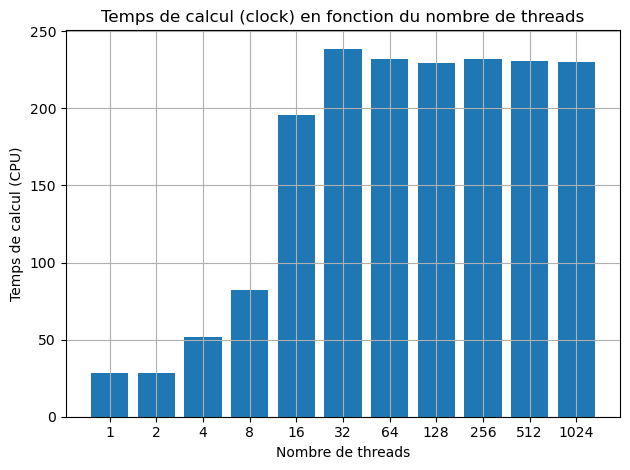

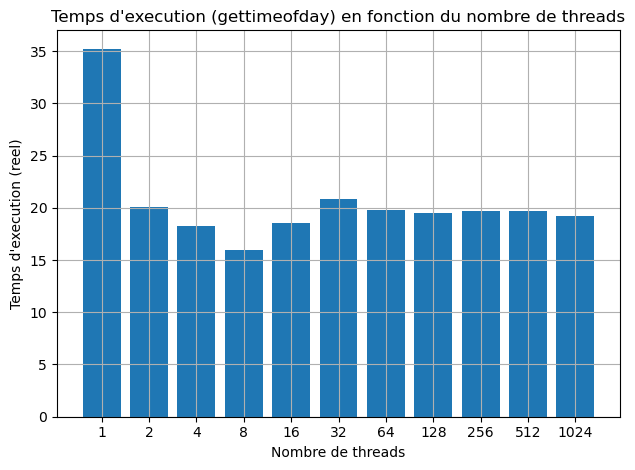

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultats2.csv")
df.columns = [c.strip() for c in df.columns]

df = df.rename(columns={
    "Nombre de threads": "Threads",
    "temps_calcul": "CPU",
    "temps_execution": "EXEC"
})

df["Threads"] = pd.to_numeric(df["Threads"], errors="coerce")
df["CPU"] = pd.to_numeric(df["CPU"], errors="coerce")
df["EXEC"] = pd.to_numeric(df["EXEC"], errors="coerce")
df = df.dropna(subset=["Threads", "CPU", "EXEC"]).sort_values("Threads")

x = range(len(df))
labels = df["Threads"].astype(int).astype(str)

plt.figure()
plt.bar(x, df["CPU"])
plt.xticks(x, labels)
plt.xlabel("Nombre de threads")
plt.ylabel("Temps de calcul (CPU)")
plt.title("Temps de calcul (clock) en fonction du nombre de threads")
plt.grid(True)
plt.tight_layout()
plt.savefig("graph_temps_calcul.png", dpi=200)
plt.show()

plt.figure()
plt.bar(x, df["EXEC"])
plt.xticks(x, labels)
plt.xlabel("Nombre de threads")
plt.ylabel("Temps d'execution (reel)")
plt.title("Temps d'execution (gettimeofday) en fonction du nombre de threads")
plt.grid(True)
plt.tight_layout()
plt.savefig("graph_temps_execution.png", dpi=200)
plt.show()
